# Método do Cotovelo para o Dataset Dry Bean (KMeans)

Este notebook permite analisar o número ideal de clusters para o dataset Dry Bean utilizando o método do cotovelo com KMeans.

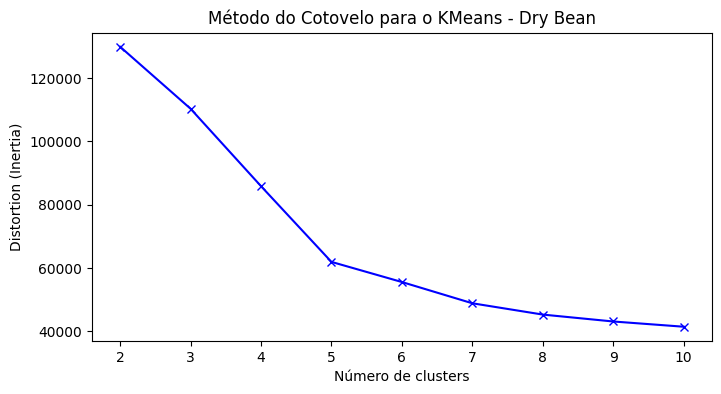

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Carregamento e pré-processamento do dataset Dry Bean
bean_df = pd.read_excel('data/DryBeanDataset/Dry_Bean_Dataset.xlsx')
bean_df = bean_df.dropna()
for col in bean_df.select_dtypes(include='object').columns:
    bean_df[col] = LabelEncoder().fit_transform(bean_df[col].astype(str))
X = bean_df.drop('Class', axis=1).values
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Método do cotovelo
K = range(2, 11)
distortions = []
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    distortions.append(kmeans.inertia_)

plt.figure(figsize=(8,4))
plt.plot(K, distortions, 'bx-')
plt.xlabel('Número de clusters')
plt.ylabel('Distortion (Inertia)')
plt.title('Método do Cotovelo para o KMeans - Dry Bean')
plt.savefig('img/kmeans_drybean_elbow.png')
plt.show()